## GPT因子工厂

- 模拟构建三个大语言模型智能体：FactorGPT、CodeGPT与 EvalGPT。目标是让这三个“智能体”协同工作，完成从因子生成、代码生成、到因子回测与优化建议输出的闭环

### 目标：
#### 1.模拟 FactorGPT 自动生成因子表达式
#### 2.使用 CodeGPT 将因子表达式转化为 Python 可执行代码，并计算因子值（包含自动debug循环）
#### 3.模拟 EvalGPT 进行回测并提出优化建议
#### 4.基于优化建议继续优化当前因子

- 首先导入代码所需的库。本次实验使用 DeepSeek-V3.2 的API。

In [1]:
import os
import re
from openai import OpenAI
import pandas as pd
import numpy as np
import traceback
from scipy.stats import spearmanr, pearsonr
import matplotlib as plt
import random
np.random.seed(42)
random.seed(42)

## FactorGPT：因子表达式生成器

In [2]:
class FactorConfig:
    """
    定义因子工厂的配置信息(包含可用字段和算子)
    """
    
    # 基础量价字段
    FIELDS = [
        "S_DQ_OPEN",   # 开盘价
        "S_DQ_HIGH",   # 最高价
        "S_DQ_LOW",    # 最低价
        "S_DQ_CLOSE",  # 收盘价
        "S_DQ_VOLUME"  # 成交量
    ]

    # 可用算子列表
    OPERATORS_DICT = {
        # 基础运算
        "Abs(X)": "返回X中每个元素的绝对值",
        "Sign(X)": "返回X中每个元素的符号（1为正，0为0，-1为负）",
        "Log(X)": "返回X中每个元素的自然对数",
        "Exp(X)": "返回X中每个元素的指数函数值",
        "Sqrt(X)": "返回X中每个元素的平方根",
        "Inv(X)": "返回X中每个元素的倒数（1除以每个元素）",
        "Pow(X, y)": "返回X中每个元素的幂运算值",
        
        # 基本面专用元素算子
        "YOY(X)": "对X进行同比处理",
        "QOQ(X)": "对X进行环比处理",
        
        # 关系算子
        "Add(X, Y)": "将X,Y逐元素相加并返回结果",
        "Sub(X, Y)": "从X中逐元素减去Y并返回结果",
        "Mul(X, Y)": "将X和Y逐元素相乘并返回结果",
        "Div(X, Y)": "将X逐元素除以Y并返回结果",

        # 截面算子
        "CS_Rank(X)": "对X进行截面排序",
        "CS_Indus_Rank(X, indus_belong)": "对X进行行业截面排序",
        
        # 排序复合算子
        "Rank_Add(X, Y)": "返回X中元素的分位数和Y中对应元素的分位数的和",
        "Rank_Sub(X, Y)": "返回X中元素的分位数和Y中对应元素的分位数的差",
        "Rank_Mul(X, Y)": "返回X中元素的分位数和Y中对应元素的分位数的积",
        "Rank_Div(X, Y)": "用X中元素的分位数除以Y中对应元素的分位数并返回结果",

        # 时序算子 (基本面/日频)
        "Delay(X, d)": "返回过去第d个季度的X值",
        "TS_Corr(X, Y, d)": "过去d季度X值构成的时序数列和Y值构成的时序数列的相关系数",
        "TS_Std(X, d)": "过去d季度X值的标准差",
        "TS_Min(X, d)": "过去d季度X值构成的时序数列中最小值",
        "TS_Max(X, d)": "过去d季度X值构成的时序数列中最大值",
        "TS_Mean(X, d)": "过去d季度X值构成的时序数列的平均值",
        "TS_Sum(X, d)": "过去d季度X值构成的时序数列之和",

        # 高频：聚合算子
        "Agg_Std(X)": "返回序列X的标准差",
        "Agg_Var(X)": "返回序列X的方差",
        "Agg_Mean(X)": "返回序列X的均值",
        "Agg_Median(X)": "返回序列X的中位数",
        "Agg_Sum(X)": "返回序列X的加和",
        "Agg_Max(X)": "返回序列X的最大值",
        "Agg_Min(X)": "返回序列X的最小值",
        "Agg_Argmax(X)": "返回序列X的最大值的索引值",
        "Agg_Argmin(X)": "返回序列X的最小值的索引值",
        "Agg_Skew(X)": "返回序列X的偏度",
        "Agg_Kurt(X)": "返回序列X的峰度",
        "Agg_Corr(X, Y)": "返回序列X与Y的相关系数",
        "Agg_Cov(X, Y)": "返回序列X与Y的协方差",
        "Agg_Quantile(X, q)": "返回序列X的q分位数",

        # 高频：聚合展开算子
        "Agg_Explode_Return(X, m=1)": "返回序列X的分钟收益率，m默认为1",
        "Agg_Explode_Cumsum(X)": "返回序列X的累加序列",
        "Agg_Explode_Cumprod(X)": "返回序列X的累乘序列",
        "Agg_Explode_Cummin(X)": "返回序列X的累加序列滚动最小值",
        "Agg_Explode_Cummax(X)": "返回序列X的累加序列滚动最大值",
        "Agg_Explode_Ewmmean(X, half_life=10)": "返回序列X的指数加权移动平均，half_life默认为10",
        "Agg_Explode_Ewmstd(X, half_life=10)": "返回序列X的指数加权移动标准差，half_life默认为10",
        "Agg_Explode_Ewmvar(X, half_life=10)": "返回序列X的指数加权移动方差，half_life默认为10",
        "Agg_Explode_Rollingmean(X, window_size=10)": "返回序列X的滚动均值，window_size默认为10",
        "Agg_Explode_Rollingstd(X, window_size=10)": "返回序列X的滚动标准差，window_size默认为10",
        "Agg_Explode_Rollingvar(X, window_size=10)": "返回序列X的滚动方差，window_size默认为10",
        "Agg_Explode_Rollingskew(X, window_size=10)": "返回序列X的滚动偏度，window_size默认为10",
        "Agg_Explode_Rollingmin(X, window_size=10)": "返回序列X的滚动最小值，window_size默认为10",
        "Agg_Explode_Rollingmax(X, window_size=10)": "返回序列X的滚动最大值，window_size默认为10",
        "Agg_Explode_Rollingsum(X, window_size=10)": "返回序列X的滚动求和，window_size默认为10",
        "Agg_Explode_Rollingquantile(X, window_size=10, q=0.25)": "返回序列X的滚动q分位数，window_size默认为10，q默认为0.25",

        # 采样算子
        "Tp_Sample(X, h=15, m=0)": "返回序列X的特定时点采样"
    }
    
    @staticmethod
    def get_instruction_text():
        """
        生成包含详细定义的可用算子
        """
        #fields_str = ", ".join(FactorConfig.FIELDS)
        
        # 可用算子： "算子名: 定义"
        ops_instruction = []
        for op, desc in FactorConfig.OPERATORS_DICT.items():
            ops_instruction.append(f"- {op}: {desc}")
        
        ops_str = "\n".join(ops_instruction)
        
        return f"【可用算子及其含义】\n{ops_str}"

In [3]:
class FactorGPT:
    def __init__(self, api_key=None, model_name='deepseek-reasoner'):
        # API Key
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.deepseek.com"
        )
        self.model_name = model_name
        
        # 定义 System Prompt
        # 设定角色为“全球顶级量化对冲基金的资深高级量化研究员”
        self.system_prompt = (
            "您是一位全球顶级量化对冲基金的资深高级量化研究员，极其擅长挖掘和构造量价因子。"
            "您的日常任务是从量价数据中构建蕴含高额稳定alpha的量价选股因子。"
        )

    def _build_messages(self, optimization_context=None):
        """
        构建发送给 DeepSeek 的消息列表
        """

        base_instruction = FactorConfig.get_instruction_text() # 获取可用算子
        
        # 基础任务描述
        task_content = f"""
请使用股票开盘价S_DQ_OPEN、收盘价S_DQ_CLOSE、最高价S_DQ_HIGH、最低价S_DQ_LOW、成交量S_DQ_VOLUME这五个数据，构建一个量价选股因子，并给出【计算方法】和【含义】。

您仅可使用以下这些算子来构建因子，通过对它们的组合、复合，可以构建出单个复杂且具备稳定高额alpha的因子。
{base_instruction}

要求：
1. 您仅可使用上述字段和算子进行组合。
2. 您仅需构建出一个具备稳定高额alpha的因子。请构建正向因子，即因子值越大，未来收益率越高。
3. 请严格按照下面的格式输出，不要输出多余的Markdown标记或解释。
"""

        # Few-Shot
        example_content = """
下面是一个因子的例子，请仿照它的格式给出你构造的因子：
【因子名称】
改进的一致预期...
【因子计算方法】
Div(TS_Return(S_DQ_CLOSE, 20), S_DQ_OPEN)
【因子含义】
该因子计算了过去20天的收益率与开盘价的比值...
"""

        user_content = f"{task_content}\n{example_content}"

        # 如果存在优化建议，则注入优化上下文
        if optimization_context:
            refinement_instruction = f"""
这是一次因子优化任务。
上一次构建的因子表达式：{optimization_context['old_expression']}
回测评估员给出的优化建议：{optimization_context['suggestion']}

请根据上述建议，修改并优化因子表达式。
"""
            user_content = f"{user_content}\n{refinement_instruction}"

        # 构建 DeepSeek 要求的 messages 格式
        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": user_content}
        ]
        
        return messages

    def generate_factor(self, optimization_context=None):
        """
        调用 DeepSeek API 生成因子
        """

        messages = self._build_messages(optimization_context) # 构建 messages 格式
        
        try:
            # 调用 DeepSeek API
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=messages,
                stream=False,
                temperature=1 
            )
            content = response.choices[0].message.content
            return self._parse_output(content)
        except Exception as e:
            return {"error": f"DeepSeek API Call Failed: {str(e)}"}

    def _parse_output(self, text):
        """
        解析模型输出，提取名称、公式和含义。
        """
        result = {}
        
        name_match = re.search(r"【因子名称】\s*(.*?)\s*(?:【|$)", text, re.DOTALL) # 提取因子名称
        formula_match = re.search(r"【因子计算方法】\s*(.*?)\s*(?:【|$)", text, re.DOTALL) # 提取因子计算方法
        meaning_match = re.search(r"【因子含义】\s*(.*?)\s*(?:【|$)", text, re.DOTALL) # 提取因子含义
        
        if name_match: result['name'] = name_match.group(1).strip()
        if formula_match: result['formula'] = formula_match.group(1).strip()
        if meaning_match: result['meaning'] = meaning_match.group(1).strip()
        
        result['raw_text'] = text
        return result

## CodeGPT：因子代码执行器

In [4]:
class CodeGPT:
    def __init__(self, api_key=None, model_name='deepseek-reasoner'):
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.deepseek.com"
        )
        self.model_name = model_name
        
        # System Prompt: 设定程序员角色 
        self.system_prompt = (
            """您是一位全球顶级对冲基金公司精通Python的资深高级程序员，极其擅长编写Python代码。
请您按照用户的要求编写计算因子的代码，要求完全准确无误。请严格按照下面的格式进行输出：
```python\n<代码内容>\n```
例如：
用户输入表达式：Sub(S_DQ_CLOSE, S_DQ_OPEN)
你的输出应为：
```python
import pandas as pd
import numpy as np

# 1. 先定义算子
def Sub(x, y):
    return x - y

# 2. 再写计算主函数
def calculate_factor():
    close = pd.read_pickle('S_DQ_CLOSE.pkl')
    open_price = pd.read_pickle('S_DQ_OPEN.pkl')
    return Sub(close, open_price)""")

    def _build_task_prompt(self, expression,meaning):
        """构建user Prompt"""
        return f"""
请将以下因子表达式转化为 Python 函数代码：
因子表达式: {expression}
因子含义: {meaning}

【数据环境说明】
1. 当前目录下存在以下 .pkl 文件，索引为日期，列名为股票代码：
   - "S_DQ_OPEN.pkl" (开盘价)
   - "S_DQ_HIGH.pkl" (最高价)
   - "S_DQ_LOW.pkl" (最低价)
   - "S_DQ_CLOSE.pkl" (收盘价)
   - "S_DQ_VOLUME.pkl" (成交量)

【代码要求】
1. 请编写一个名为 `calculate_factor()` 的函数。
2. 函数内部需使用 `pd.read_pickle('文件名.pkl')` 读取所需数据，注意数据读取的完整性和正确性以及对异常值的处理。
3. 对于计算步骤中的算子，请务必定义其同名函数得到代码，并将其写在新的函数之前。这一点对于得到正确结果很重要。
4. 代码常见的报错为某个算子函数未定义，如'name 'Sub' is not defined'，请务必定义所有用到的算子函数。
5. 函数最终返回一个 DataFrame（因子值）。
6. 只输出 Python 代码块，不要输出其他解释。

【算子实现参考库】
以下常见算子已经预定义并实现，请直接在代码中调用它们：

import numpy as np
import pandas as pd

# 1. 基础运算（包含除0处理）
def Add(x, y): return x + y
def Sub(x, y): return x - y
def Mul(x, y): return x * y

def Div(x, y):
    # 处理除以0的情况：将无穷大替换为NaN
    with np.errstate(divide='ignore', invalid='ignore'):
        res = x / y
    res = res.replace([np.inf, -np.inf], np.nan)
    return res

# 2. 数学函数（包含定义域检查）
def Abs(x): return x.abs()
def Sign(x): return np.sign(x)

def Log(x):
    # 负数或0取对数返回NaN
    return np.log(x.where(x > 0))

def Sqrt(x):
    # 负数开根号返回NaN
    return np.sqrt(x.where(x >= 0))

def Inv(x):
    # 倒数，同Div处理
    with np.errstate(divide='ignore', invalid='ignore'):
        res = 1 / x
    res = res.replace([np.inf, -np.inf], np.nan)
    return res

# 3. 时序算子
def Delay(x, d): return x.shift(d)
def TS_Mean(x, d): return x.rolling(window=d).mean()
def TS_Max(x, d): return x.rolling(window=d).max()
def TS_Min(x, d): return x.rolling(window=d).min()
def TS_Sum(x, d): return x.rolling(window=d).sum()
def TS_Std(x, d): return x.rolling(window=d).std()

def TS_Return(x, d):
    # 收益率 = (x - delay(x)) / delay(x)
    # 同样需要处理分母为0的情况
    shifted = x.shift(d)
    return Div(x - shifted, shifted)

def TS_Corr(x, y, d): return x.rolling(window=d).corr(y)

def Decay_Linear(x, d):
    # 线性衰减加权
    weights = np.arange(1, d + 1)
    weights = weights / weights.sum()
    return x.rolling(d).apply(lambda z: np.dot(z, weights), raw=True)

# 4. 截面/排序算子
def Rank(x): return x.rank(axis=1, pct=True)
def Rank_Mul(x, y): return x.rank(axis=1, pct=True) * y.rank(axis=1, pct=True)
def Rank_Div(x, y): return Div(x.rank(axis=1, pct=True), y.rank(axis=1, pct=True))
def Rank_Add(x, y): return x.rank(axis=1, pct=True) + y.rank(axis=1, pct=True)
def Rank_Sub(x, y): return x.rank(axis=1, pct=True) - y.rank(axis=1, pct=True)
"""

    def _extract_code(self, text):
        """从 Markdown 中提取代码"""
        match = re.search(r"```python\s*(.*?)```", text, re.DOTALL)
        if match:
            return match.group(1)
        return text
    
    def _get_predefined_operators(self):
        """返回预定义的算子函数代码"""
        return '''
import numpy as np
import pandas as pd

# 1. 基础运算（包含除0处理）
def Add(x, y): return x + y
def Sub(x, y): return x - y
def Mul(x, y): return x * y

def Div(x, y):
    with np.errstate(divide='ignore', invalid='ignore'):
        res = x / y
    if isinstance(res, pd.DataFrame):
        res = res.replace([np.inf, -np.inf], np.nan)
    elif isinstance(res, pd.Series):
        res = res.replace([np.inf, -np.inf], np.nan)
    return res

# 2. 数学函数（包含定义域检查）
def Abs(x): return x.abs() if hasattr(x, 'abs') else np.abs(x)
def Sign(x): return np.sign(x)
def Log(x): return np.log(x.where(x > 0) if hasattr(x, 'where') else np.where(x > 0, x, np.nan))
def Exp(x): return np.exp(x)
def Sqrt(x): return np.sqrt(x.where(x >= 0) if hasattr(x, 'where') else np.where(x >= 0, x, np.nan))
def Pow(x, y): return np.power(x, y)

def Inv(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        res = 1 / x
    if isinstance(res, (pd.DataFrame, pd.Series)):
        res = res.replace([np.inf, -np.inf], np.nan)
    return res

# 3. 时序算子
def Delay(x, d): return x.shift(d)
def TS_Mean(x, d): return x.rolling(window=d, min_periods=1).mean()
def TS_Max(x, d): return x.rolling(window=d, min_periods=1).max()
def TS_Min(x, d): return x.rolling(window=d, min_periods=1).min()
def TS_Sum(x, d): return x.rolling(window=d, min_periods=1).sum()
def TS_Std(x, d): return x.rolling(window=d, min_periods=1).std()
def TS_Corr(x, y, d): return x.rolling(window=d, min_periods=1).corr(y)

def TS_Return(x, d):
    shifted = x.shift(d)
    return Div(x - shifted, shifted)

def Decay_Linear(x, d):
    weights = np.arange(1, d + 1)
    weights = weights / weights.sum()
    return x.rolling(d, min_periods=1).apply(lambda z: np.dot(z[-len(weights):], weights[-len(z):]) if len(z) > 0 else np.nan, raw=True)

# 4. 截面/排序算子
def Rank(x): return x.rank(axis=1, pct=True)
def CS_Rank(x): return x.rank(axis=1, pct=True)
def Rank_Mul(x, y): return x.rank(axis=1, pct=True) * y.rank(axis=1, pct=True)
def Rank_Div(x, y): return Div(x.rank(axis=1, pct=True), y.rank(axis=1, pct=True))
def Rank_Add(x, y): return x.rank(axis=1, pct=True) + y.rank(axis=1, pct=True)
def Rank_Sub(x, y): return x.rank(axis=1, pct=True) - y.rank(axis=1, pct=True)
'''

    def solve_factor(self, expression, meaning, max_retries=3):
        """
        生成代码 -> 执行 -> 报错则重试 
        """
        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": self._build_task_prompt(expression, meaning)}
        ]
        
        # 预先注入算子定义到执行环境
        predefined_operators = self._get_predefined_operators()

        for attempt in range(max_retries + 1):
            print(f"\n[CodeGPT] 第 {attempt + 1} 次尝试生成代码...")
            
            try:
                response = self.client.chat.completions.create(
                    model=self.model_name,
                    messages=messages,
                    stream=False,
                    temperature=0.1 # 代码生成需要较低的随机性
                )
                raw_content = response.choices[0].message.content
                code_str = self._extract_code(raw_content) # 提取代码
                
                # 记录生成的代码
                #print(f"生成的代码 (摘要)\n{code_str[:200]}...\n")

                local_scope = {}
                exec(predefined_operators, globals(), local_scope) 
                exec(code_str, {**globals(), **local_scope}, local_scope)  # 执行生成代码
                if 'calculate_factor' not in local_scope:
                    raise ValueError("生成的代码中未找到 `calculate_factor` 函数定义。")
                
                # 运行calculate_factor
                print("[CodeGPT] 正在计算因子...")
                result_df = local_scope['calculate_factor']()
                print("[CodeGPT] 执行成功！")
                return result_df, code_str

            except Exception as e:
                error_msg = traceback.format_exc()
                print(f"[CodeGPT]运行报错: {e}")
                
                # 达到最大重试次数，抛出异常
                if attempt == max_retries:
                    print("[CodeGPT]达到最大重试次数，任务失败。")
                    return None, None
                
                # Debug
                debug_instruction = f"""
你在上一次生成的代码运行时发生了错误。
报错信息如下：
{error_msg}

请分析错误原因，并重写完整的 Python 代码以修复此错误。
保持函数名 `calculate_factor` 不变。
"""
                # 将错误信息追加到对话历史中，形成上下文
                messages.append({"role": "assistant", "content": raw_content})
                messages.append({"role": "user", "content": debug_instruction})

## EvalGPT: 因子回测与优化

- Test类：用于计算回测结果，包含IC值、RankIC值和分层收益，并绘图

In [5]:
class Test:
    """
    计算因子的回测指标: IC, RankIC, 年化收益率（支持日/周/月频）。
    """
    
    @staticmethod
    def rm_outliers(series, n=3):
        """
        去极值：3倍标准差
        """
        if series.empty: return series
        mean = series.mean()
        std = series.std()
        up = mean + n * std # 上界
        down = mean - n * std # 下界
        return series.clip(lower=down, upper=up) # clip函数将超出区间的值截断
    
    @staticmethod
    def standardize(series):
        """
        标准化：Z-Score
        """
        if series.std() == 0: return series
        return (series - series.mean()) / series.std()
    
    @staticmethod
    def get_forward_returns(factor_data, freq='D'):
        """
        获取下期收益率
        factor_data: 因子数据
        freq: 回测频率 'D'(日), 'W'(周), 'M'(月)
        """
        close = pd.read_pickle('S_DQ_ADJCLOSE.pkl') # 用后复权收盘价进行回测
        # 确保索引格式一致
        if not isinstance(close.index, pd.DatetimeIndex):
            close.index = pd.to_datetime(close.index)
        if not isinstance(factor_data.index, pd.DatetimeIndex):
            factor_data.index = pd.to_datetime(factor_data.index)

        close = close[factor_data.columns]
        
        # 提取因子存在的日期索引
        factor_dates = factor_data.index.sort_values()     
           
        # 获取与因子索引匹配的收盘价
        price = close.reindex(factor_dates, method='ffill')
    
        next_price = price.shift(-1) # 下期价格
        
        # 计算下期收益率
        next_ret = next_price / price - 1
        
        return next_ret

    @staticmethod
    def calculate_cagr(returns_series, periods_per_year):
        """
        计算精确的年化收益率
        returns_series: 收益率序列
        periods_per_year: 一年多少个周期 (日252, 周52, 月12)
        """
        # 使用复利公式: (1 + r1)(1 + r2)... - 1
        cum_ret = (1 + returns_series.fillna(0)).prod() - 1
        
        n_periods = len(returns_series)
        if n_periods == 0:
            return 0.0
        
        # 年数
        years = n_periods / periods_per_year
        
        # 避免 years 太小导致指数爆炸
        if years < 0.1: 
            # 时间太短使用简单年化
            return returns_series.mean() * periods_per_year
            
        # CAGR 公式: (End_Value / Start_Value)^(1/n) - 1
        cagr = (1 + cum_ret) ** (1 / years) - 1
        return cagr

    @staticmethod
    def calculate(factor_data, freq='D'):
        """
        计算 IC, RankIC 和 分层收益。
        factor_data: 因子数据
        freq: 回测频率，默认为 'D'。可选 'W-FRI' (周频周五), 'M' (月频月底) 等 pandas resample 字符串
        """
       
        if freq != 'D':
            factor_data_resampled = factor_data.resample(freq).last()
        else:
            factor_data_resampled = factor_data.copy()
            
        # 确定一年有多少个周期 (用于年化计算)
        if 'W' in freq:
            periods_per_year = 52 # 周频
        elif 'M' in freq:
            periods_per_year = 12 # 月频
        else:
            periods_per_year = 252 # 日频

        # 获取对应频率的下期收益率
        next_ret = Test.get_forward_returns(factor_data_resampled, freq=freq)
        
        ic_series = [] 
        rank_ic_series = [] 
        layer_returns = [] 
        valid_dates = [] 
        
        for date in factor_data_resampled.index:
            f_row = factor_data_resampled.loc[date]
            r_row = next_ret.loc[date]
            
            # 剔除无效值
            valid_mask = ~(np.isnan(f_row) | np.isnan(r_row) | np.isinf(f_row) | np.isinf(r_row))
            if valid_mask.sum() < 5: # 至少要有5只股票才能分5层
                continue
                
            f_valid = f_row[valid_mask]
            r_valid = r_row[valid_mask]
                 
            # 去极值：3倍标准差
            f_valid = Test.rm_outliers(f_valid, n=3)
            
            # 标准化：Z-Score
            f_valid = Test.standardize(f_valid)
            
            # 检查是否为常数数组（标准差为0），避免相关系数计算警告
            if f_valid.std() == 0 or r_valid.std() == 0:
                continue
                        
            try:
                # 分组
                groups_raw = pd.qcut(f_valid, 5, labels=False, duplicates='drop')
                n_groups = groups_raw.nunique()
                
                # 根据分组数动态生成labels，Layer5因子值最小，Layer1因子值最大
                if n_groups == 5:
                    labels = ['Layer5', 'Layer4', 'Layer3', 'Layer2', 'Layer1']
                else:
                    # 分组数不足5时，使用实际分组数对应的labels
                    all_labels = ['Layer5', 'Layer4', 'Layer3', 'Layer2', 'Layer1']
                    labels = all_labels[-n_groups:]  
                
                groups = pd.qcut(f_valid, 5, labels=labels, duplicates='drop')
                
                # 计算每层的等权平均收益
                layer_ret = r_valid.groupby(groups).mean()
                
                # 记录当前期结果
                current_layer = []
                for layer_name in ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5']:
                    current_layer.append(layer_ret.get(layer_name, np.nan))
                    
                # 计算 IC / RankIC
                ic, _ = pearsonr(f_valid, r_valid)
                rank_ic, _ = spearmanr(f_valid, r_valid)
                
                ic_series.append(ic)
                rank_ic_series.append(rank_ic)
                layer_returns.append(current_layer)
                valid_dates.append(date)
                
            except Exception as e:
                print(f"[EvalGPT] 回测分层计算失败，跳过日期 {date}，错误: {e}")
                continue
        
        df_layers = pd.DataFrame(layer_returns, index=valid_dates, columns=['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5'])
        df_ic = pd.DataFrame({'IC': ic_series}, index=valid_dates)
        df_RankIC = pd.DataFrame({'RankIC': rank_ic_series}, index=valid_dates)
        
        # 根据 RankIC 均值确定多空方向（负向因子做空以获取正收益）
        rank_ic_mean = np.mean(rank_ic_series) if len(rank_ic_series) > 0 else 0.0
        direction = 1 if rank_ic_mean >= 0 else -1
        
        # 计算多空对冲收益：方向 * (Layer1 - Layer5)
        long_short_ret = direction * (df_layers['Layer1'] - df_layers['Layer5'])
        
        # 计算精确年化指标
        cagr = Test.calculate_cagr(long_short_ret, periods_per_year)
        
        metrics = {
            "IC_Mean": np.mean(ic_series),
            "IC_Std": np.std(ic_series),
            "IC_IR": np.mean(ic_series) / np.std(ic_series) if np.std(ic_series) != 0 else 0,
            "RankIC_Mean": rank_ic_mean,
            "RankIC_Std": np.std(rank_ic_series),
            "RankIC_IR": rank_ic_mean / np.std(rank_ic_series) if np.std(rank_ic_series) != 0 else 0,
            "CAGR": cagr, # 精确年化收益（方向已按 RankIC 均值调整）
            "Direction": '正向做多' if direction == 1 else '反向做空'
        }
            
        result = pd.concat([df_ic, df_RankIC, df_layers], axis=1)
        
        # 格式化报告
        report_str = (
            f"回测频率: {freq} (每年约 {periods_per_year} 期)\n"
            f"IC均值: {metrics['IC_Mean']:.4f}, ICIR: {metrics['IC_IR']:.4f}\n"
            f"RankIC均值: {metrics['RankIC_Mean']:.4f}, RankIC_IR: {metrics['RankIC_IR']:.4f}\n"
            f"方向: {metrics['Direction']}\n"
            f"多空年化收益: {metrics['CAGR']:.2%}"
        )
        
        return result, metrics, report_str
    
    @staticmethod
    def plot(test_results):
        """
        绘制累积IC、累积RankIC 和 5分层累积收益图（分开绘制三张独立图）
        """
        import matplotlib.pyplot as plt
        try:
            import seaborn as sns
            sns.set_theme(style="whitegrid")
            plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
            plt.rcParams['axes.unicode_minus'] = False
        except:
            pass

        for name, df in test_results.items():
            if df.empty: continue
            
            factor_name = name.replace('_test', '')
            
            # 累积 IC (单利计算)
            fig0, ax0 = plt.subplots(figsize=(12, 6))
            df['IC'].cumsum().plot(ax=ax0, color='darkgreen', linewidth=1.5)
            ax0.set_title(f'{factor_name} - 累积 IC', fontsize=12, fontweight='bold')
            ax0.set_xlabel('日期')
            ax0.set_ylabel('累积IC')
            ax0.axhline(0, color='black', linestyle='--', linewidth=0.8)
            plt.tight_layout()
            plt.show()
            
            # 累积 RankIC (单利计算)
            fig1, ax1 = plt.subplots(figsize=(12, 6))
            df['RankIC'].cumsum().plot(ax=ax1, color='navy', linewidth=1.5)
            ax1.set_title(f'{factor_name} - 累积 RankIC', fontsize=12, fontweight='bold')
            ax1.set_xlabel('日期')
            ax1.set_ylabel('累积RankIC')
            ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
            plt.tight_layout()
            plt.show()
            
            # 5分层累积收益率（复利计算）
            fig2, ax2 = plt.subplots(figsize=(12, 6))
            layers = df[['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5']].fillna(0) 
            # 净值计算：(1 + ret).cumprod()
            layers_nav = (1 + layers).cumprod()
            valid_layers = [col for col in layers.columns if layers[col].notna().any()]
            # Layer1 (最大) 用红色，Layer5 (最小) 用蓝色，中间渐变
            color_map = {'Layer1': '#d73027', 'Layer2': '#fc8d59', 'Layer3': '#fee090', 
                         'Layer4': '#91bfdb', 'Layer5': '#4575b4'}
            colors = [color_map[col] for col in valid_layers]
            
            layers_nav[valid_layers].plot(ax=ax2, color=colors, linewidth=1.5)
            ax2.set_title(f'{factor_name} - 5分层净值曲线 (复利, Layer1因子值最大)', fontsize=12, fontweight='bold')
            ax2.set_xlabel('日期')
            ax2.set_ylabel('净值')
            ax2.legend(loc='upper left')
            plt.tight_layout()
            plt.show()

- EvalGPT：调用上面的Test类进行回测，并根据回测结果对因子做出评价和优化建议

In [6]:
class EvalGPT:
    def __init__(self, api_key=None, model_name='deepseek-reasoner'):
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://api.deepseek.com"
        )
        self.model_name = model_name
        
        # System Prompt: 设定资深量化研究员角色
        self.system_prompt = (
            "您是一位全球顶级对冲基金的资深高级研究员，负责因子的效果评估工作。"
            "请您根据量价因子的名称、计算方法、含义、回测结果，给出对该因子的评估结果和优化建议。\n"
            "您的优化原则是：\n"
            "1. 尽量提高量价因子的RankIC指标的绝对值；\n"
            "2. 尽量降低量价因子的RankIC指标的标准差（提高稳定性）；\n"
            "3. 尽量提高量价因子的因子收益率均值。\n\n"
            "请严格按照下面的格式进行回答：\n"
            "【量价因子评估结果】\n..."
            "【量价因子优化建议】\n..."
        )

    def evaluate(self, factor_info, factor_data):
        """
        1. 调用 Test 类计算回测指标。
        2. 构建 Prompt 调用大模型生成评价。
        """
        print("[EvalGPT] 正在进行回测计算...")
    
        res,metrics,report = Test.calculate(factor_data,freq='W-FRI') # 调用Test类中的函数计算回测指标
        
        print(f"[EvalGPT] 回测完成。\n回测报告】：\n{report}\n")
        print("[EvalGPT] 正在绘图...")
        factor_name = factor_info.get('name', 'Factor')
        test_results = {factor_name: res}
        Test.plot(test_results) # 调用绘图函数，绘制累计IC/RankIC/分层收益图
    
        # 构建 User Prompt
        user_content = f"""
以下是当前因子的详细信息及回测绩效，请进行解读并提出优化建议。

【因子名称】
{factor_info.get('name')}

【因子计算方法】
{factor_info.get('formula')}

【因子含义】
{factor_info.get('meaning')}

【回测结果】
{report}

请根据以上信息，解读回测结果（是否有效、是否稳定），并提出具体的数学公式层面的优化建议（例如调整算子、改变时间窗口、增加过滤条件等）。
"""

        messages = [
            {"role": "system", "content": self.system_prompt},
            {"role": "user", "content": user_content}
        ]

        # 调用大模型
        try:
            print("[EvalGPT] 正在生成评估报告...")
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=messages,
                stream=False,
                temperature=0.8
            )
            content = response.choices[0].message.content
            suggestion = self._extract_suggestion(content)
            print("[EvalGPT] 评估报告生成完成。")
            return {
                "report": content,      # 完整的文本报告
                "metrics": metrics,     # 回测指标
                "suggestion": suggestion # 提取出的优化建议文本
            }
            
        except Exception as e:
            return {"error": str(e)}

    def _extract_suggestion(self, text):
        """
        提取【量价因子优化建议】部分，以便传回给 FactorGPT。
        """
        match = re.search(r"【量价因子优化建议】\s*(.*)", text, re.DOTALL)
        if match:
            return match.group(1).strip()
        return text  

#### 接下来让FactorGPT、CodeGPT和EvalGPT协同工作，完成从因子生成、代码生成、到因子回测与优化建议输出的闭环

- 首先调用FactorGPT，自动生成因子表达式

In [7]:
api_key = "sk-94057f3f0b384d15a30ff80035367573" # DeepSeek-V3.2 的 API Key
try:
    factor_agent = FactorGPT(api_key=api_key) # 初始化 FactorGPT
            
    print("【FactorGPT】因子挖掘中...")
        
    factor_1 = factor_agent.generate_factor() # 生成因子
            
    if "error" in factor_1:
        print("【FactorGPT】API 调用出错:", factor_1["error"])            
    print(f"因子名称: {factor_1.get('name')}")
    print(f"因子公式: {factor_1.get('formula')}")
    print(f"因子含义: {factor_1.get('meaning')}...")

except Exception as e:
    print(f"【FactorGPT】运行出错: {e}")

【FactorGPT】因子挖掘中...
因子名称: 稳定放量趋势强度
因子公式: CS_Rank(
    Add(
        Log(
            TS_Corr(S_DQ_CLOSE, S_DQ_OPEN, 20)
        ),
        Log(
            Div(S_DQ_VOLUME, TS_Mean(S_DQ_VOLUME, 20))
        )
    )
)
因子含义: 该因子衡量股票价格趋势稳定性与成交量放大效应的综合强度。首先，计算过去20个季度收盘价与开盘价的时序相关系数，以捕捉价格走势的内在一致性与趋势强度，高相关性表明价格运动方向明确且稳定。其次，计算当期成交量相对于过去20个季度平均成交量的比率，以识别成交量的异常放大，通常伴随重要价格行为的确认。对这两个分量分别取自然对数以平滑分布并增强稳定性。将两个处理后的分量相加，得到一个综合的“稳定放量趋势”原始信号。最后，在截面所有股票上对该综合信号进行排序，生成最终的因子值。因子值高的股票，表明其近期同时具备稳定的价格上涨趋势和成交量放大的确认效应，这类股票未来继续上涨的概率和潜力更大。...


- 调用CodeGPT，将因子表达式转化为 Python 可执行代码，并计算因子值

In [8]:
coder = CodeGPT(api_key=api_key) # 初始化 CodeGPT
result, final_code = coder.solve_factor(factor_1.get('formula'), factor_1.get('meaning')) # 生成并执行代码
if result is None:
    print("代码生成或执行失败，无法计算因子值。")


[CodeGPT] 第 1 次尝试生成代码...
[CodeGPT] 正在计算因子...
[CodeGPT] 执行成功！


In [9]:
# 打印计算的因子值和代码
print("【CodeGPT】最后5行因子值：")
print(result.tail())
result.to_csv("factor.csv") # 因子值存储在factor.csv文件中
print("【CodeGPT】最终可执行代码")
print(final_code) 
# 可执行代码保存在 code.py 文件中
final_code_path = "code.py"
with open(final_code_path, "w", encoding="utf-8") as f:
    f.write(final_code)

【CodeGPT】最后5行因子值：
S_INFO_WINDCODE  000001.SZ  000002.SZ  000004.SZ  000005.SZ  000006.SZ  \
TRADE_DT                                                                 
2024-02-02        0.334456   0.221973   0.117911   0.143178   0.235261   
2024-02-05        0.291409   0.220101   0.103687   0.008048   0.268201   
2024-02-06        0.234887   0.181920   0.335018   0.003556   0.093019   
2024-02-07        0.244245   0.200075   0.445817   0.001123   0.034999   
2024-02-08        0.143151   0.262537   0.305576   0.996257   0.120509   

S_INFO_WINDCODE  000007.SZ  000008.SZ  000009.SZ  000010.SZ  000011.SZ  ...  \
TRADE_DT                                                                ...   
2024-02-02        0.125023   0.500655   0.365525   0.093393   0.052779  ...   
2024-02-05        0.045293   0.422235   0.326596   0.055774   0.095452  ...   
2024-02-06        0.384428   0.279431   0.349055   0.105933   0.020401  ...   
2024-02-07        0.074490   0.190717   0.903612   0.059517   0.0114

- 调用EvalGPT，进行回测并提出优化建议

【EvalGPT】开始因子回测与评估...
[EvalGPT] 正在进行回测计算...
[EvalGPT] 回测完成。
回测报告】：
回测频率: W-FRI (每年约 52 期)
IC均值: -0.0105, ICIR: -0.1332
RankIC均值: -0.0352, RankIC_IR: -0.3994
方向: 反向做空
多空年化收益: 7.04%

[EvalGPT] 正在绘图...


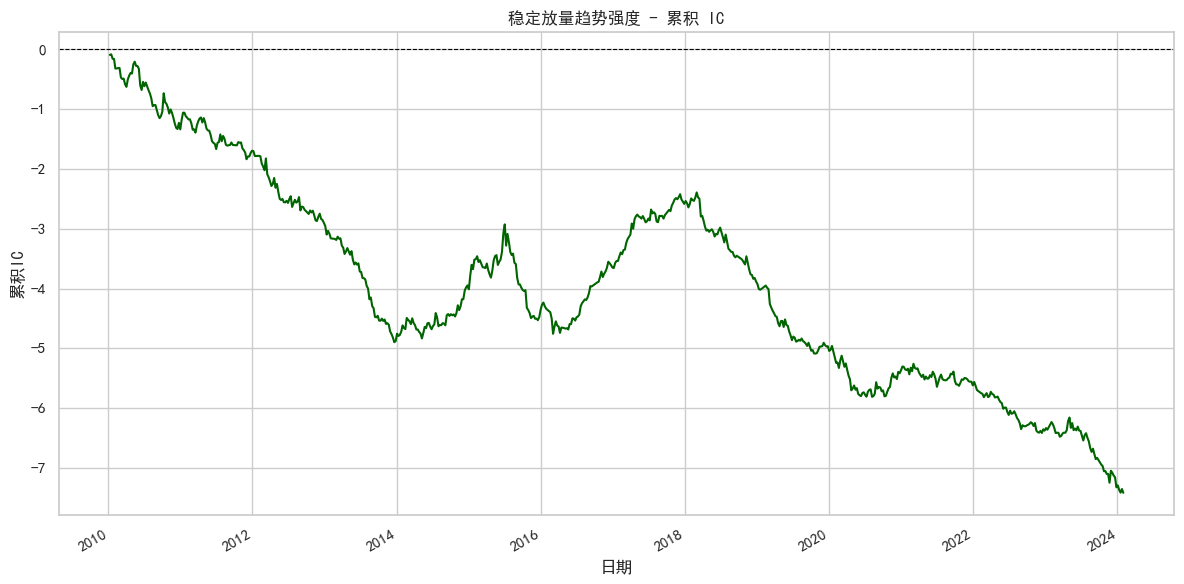

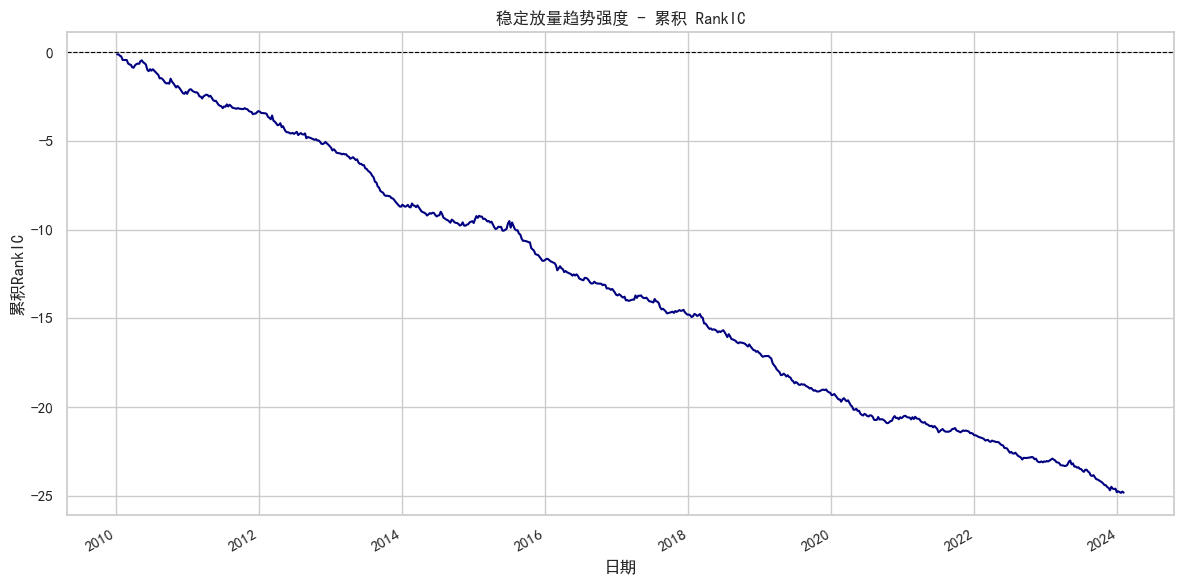

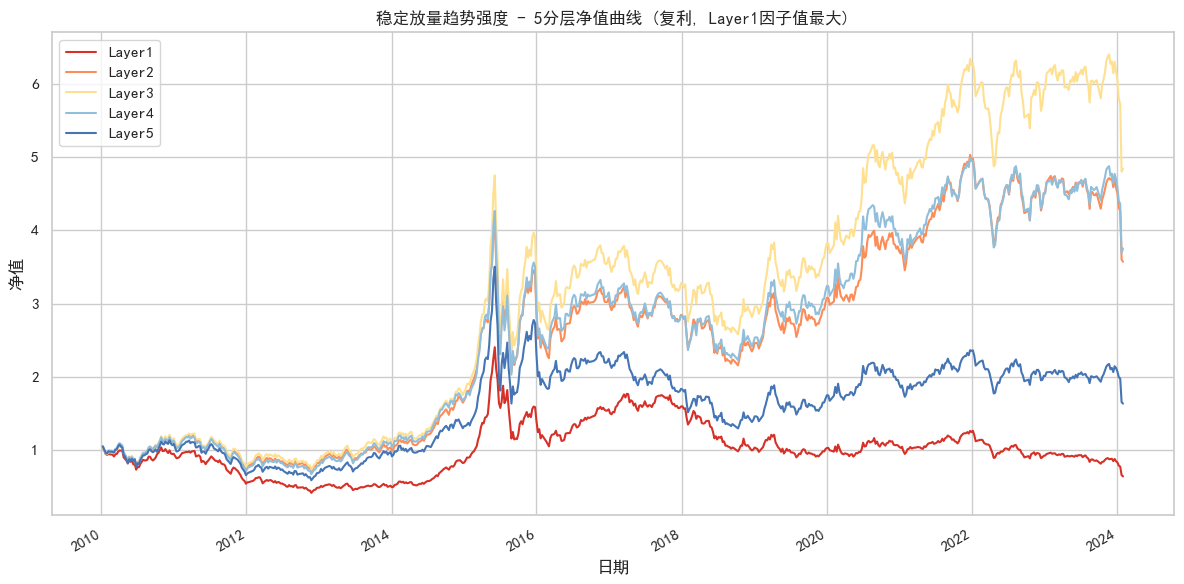

[EvalGPT] 正在生成评估报告...
[EvalGPT] 评估报告生成完成。


In [10]:
# 调用 EvalGPT 进行回测和评估
print("【EvalGPT】开始因子回测与评估...")

eval_agent = EvalGPT(api_key=api_key) # 初始化 EvalGPT
eval_result = eval_agent.evaluate(factor_1, result) # 进行回测，给出评估报告和优化建议

In [11]:
# 打印评估报告和优化建议
if "error" in eval_result:
    print(f"【EvalGPT】评估出错: {eval_result['error']}")
else:
    print("【EvalGPT 评估报告】")
    print(eval_result['report'])
    
    print("\n【优化建议】")
    print(eval_result['suggestion'])

【EvalGPT 评估报告】
【量价因子评估结果】
该因子旨在捕捉“稳定的价格上涨伴随成交量放大”这一技术面模式，但当前回测结果表现不佳，因子效果微弱且不稳定。
1.  **预测方向与预期相反**：因子原始定义认为高因子值（稳定上涨+放量）预示未来上涨潜力大，应呈现正向收益。但回测结果显示其RankIC均值为负（-0.0352），且被标记为“反向做空”，表明在实际历史数据中，呈现该模式的股票反而在接下来的时期更可能表现不佳。这与设计初衷相悖。
2.  **预测能力微弱**：RankIC均值绝对值为3.52%，低于常见的有效阈值（如5%），说明因子的截面预测能力非常弱。
3.  **稳定性极差**：RankIC_IR为-0.3994（绝对值0.3994），远低于经验上认为稳定性较好的阈值（如1.0）。这表明因子的预测方向虽然整体为负，但其效果在不同时间段内波动剧烈，非常不稳定，实际应用风险很高。
4.  **收益表现尚可但不可靠**：多空年化收益7.04%尚可，但这是在因子极不稳定的情况下取得的。低IR意味着该收益的获取过程伴随巨大的波动和回撤风险，难以在实盘中稳定复现。

**结论**：该因子在当前构造下并非一个有效的正向Alpha因子，其表现更像是一个存在周期性反转或需特定条件触发、但信号极不稳定的弱负向指标，不推荐直接使用。

【量价因子优化建议】
核心问题在于原始构造中“稳定性”与“放量”的度量方式、时间尺度以及合成方法未能有效捕捉对未来收益有持续、稳定预测力的模式。建议从以下方向进行数学公式层面的优化：

1.  **调整时间窗口与频率，聚焦近期有效信息**：
    *   **问题**：使用20个**季度**（5年）的窗口计算相关性及成交量基准，时间跨度太长，包含了大量陈旧、与当前趋势无关的信息，严重稀释了近期重要信号。
    *   **优化**：将时间窗口从“季度”调整为“日”或“周”，大幅缩短窗口长度。
        *   例如，将`TS_Corr(S_DQ_CLOSE, S_DQ_OPEN, 20)` 改为 `TS_Corr(TS_Delta(S_DQ_CLOSE, 1), TS_Delta(S_DQ_OPEN, 1), 20)` ，计算过去20日**收益率**序列的相关性，更能反映近期趋势的稳定性。
        *   将 `TS_M

- **基于EvalGPT优化建议，让FactorGPT优化因子**

In [12]:
# 构建优化上下文，包含原因子表达式和EvalGPT的优化建议
optimization_context = {
    'old_expression': factor_1.get('formula'),
    'suggestion': eval_result.get('suggestion')
}

print("【FactorGPT】开始基于EvalGPT优化建议进行因子优化...")
# print(f"\n【原因子表达式】\n{optimization_context['old_expression']}")
# print(f"\n【EvalGPT优化建议】\n{optimization_context['suggestion']}")

# 调用 FactorGPT 生成优化后的因子
factor_2 = factor_agent.generate_factor(optimization_context=optimization_context)

if "error" in factor_2:
    print("【FactorGPT】API 调用出错:", factor_2["error"])
else:
    print("\n【FactorGPT】优化后的因子：")
    print(f"因子名称: {factor_2.get('name')}")
    print(f"因子公式: {factor_2.get('formula')}")
    print(f"因子含义: {factor_2.get('meaning')}")

【FactorGPT】开始基于EvalGPT优化建议进行因子优化...

【FactorGPT】优化后的因子：
因子名称: 趋势稳健放量因子
因子公式: CS_Rank(
    Rank_Mul(
        CS_Rank(
            Div(
                TS_Sum(
                    Sub(S_DQ_CLOSE, TS_Mean(S_DQ_CLOSE, 20)),
                    20
                ),
                TS_Std(S_DQ_CLOSE, 20)
            )
        ),
        CS_Rank(
            Log(
                Div(
                    TS_Mean(S_DQ_VOLUME, 5),
                    TS_Mean(S_DQ_VOLUME, 60)
                )
            )
        )
    )
)
因子含义: 该因子旨在捕捉“趋势稳健且伴随成交量确认”的强势股模式。核心由两个在排序空间内相乘的分量构成：第一个分量是过去20日累计收益率（以收盘价相对于其20日均线的偏离度之和来近似）与其同期波动率的比值，衡量了趋势的强度和稳定性；第二个分量是5日成交量均线与60日成交量均线的比值的对数，衡量了近期成交量的趋势性放大。两个分量先各自进行截面排序以标准化，然后在排序空间内相乘，要求股票同时满足“趋势稳健”和“持续放量”两个条件，最后再次截面排序得到最终因子。因子值越大，代表股票的趋势越稳健且获得成交量支撑越强，预期未来收益率越高。


- 让CodeGPT将优化后的因子表达式转化为可执行代码

In [13]:
# 调用 CodeGPT 将优化后的因子表达式转化为可执行代码
print("【CodeGPT】生成优化因子的代码...")
result_2, final_code_2 = coder.solve_factor(factor_2.get('formula'), factor_2.get('meaning'))

if result_2 is None:
    print("【CodeGPT】代码生成或执行失败，无法计算优化后的因子值。")
else:
    print("\n【CodeGPT】优化后因子的最后5行因子值：")
    print(result_2.tail())

【CodeGPT】生成优化因子的代码...

[CodeGPT] 第 1 次尝试生成代码...
[CodeGPT] 正在计算因子...
[CodeGPT] 执行成功！

【CodeGPT】优化后因子的最后5行因子值：
S_INFO_WINDCODE  000001.SZ  000002.SZ  000004.SZ  000005.SZ  000006.SZ  \
TRADE_DT                                                                 
2024-02-02        0.950608   0.398690   0.467353   0.577175   0.938821   
2024-02-05        0.889242   0.327970   0.331712   0.374369   0.849766   
2024-02-06        0.843247   0.324916   0.315189   0.261878   0.658997   
2024-02-07        0.843621   0.401609   0.329218   0.076132   0.538346   
2024-02-08        0.831120   0.600711   0.314943   0.479708   0.404526   

S_INFO_WINDCODE  000007.SZ  000008.SZ  000009.SZ  000010.SZ  000011.SZ  ...  \
TRADE_DT                                                                ...   
2024-02-02        0.788026   0.500655   0.954911   0.497287   0.982039  ...   
2024-02-05        0.723480   0.507016   0.953789   0.452198   0.947428  ...   
2024-02-06        0.510662   0.472129   0.920688   0.434

- 调用 EvalGPT 对优化后的因子进行回测评估

【EvalGPT】对优化后的因子进行回测评估...
[EvalGPT] 正在进行回测计算...
[EvalGPT] 回测完成。
回测报告】：
回测频率: W-FRI (每年约 52 期)
IC均值: -0.0123, ICIR: -0.1227
RankIC均值: -0.0364, RankIC_IR: -0.3171
方向: 反向做空
多空年化收益: 11.50%

[EvalGPT] 正在绘图...


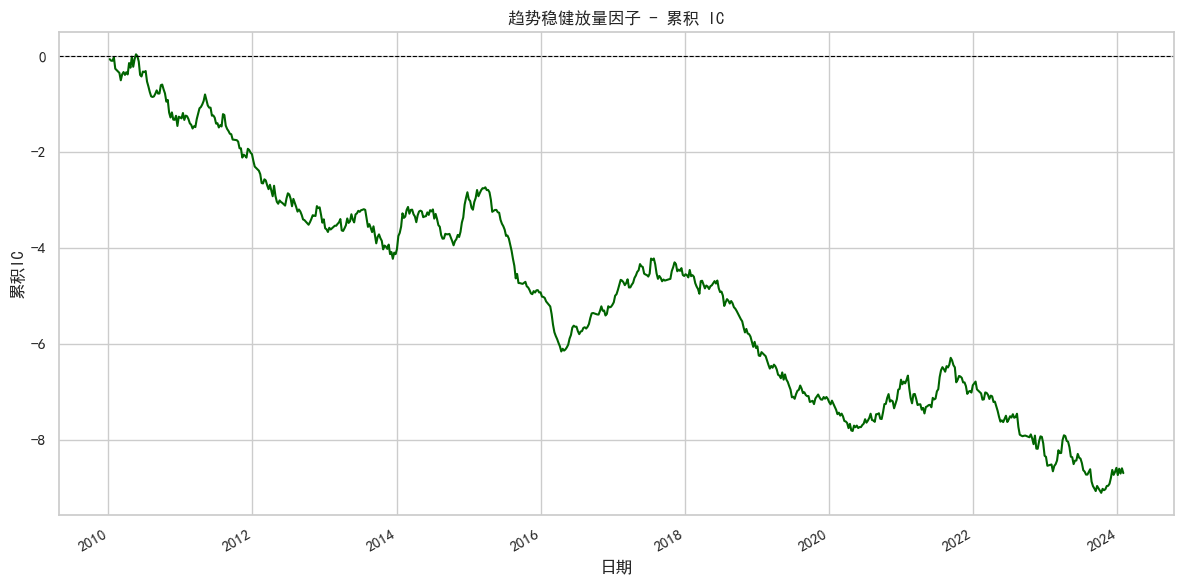

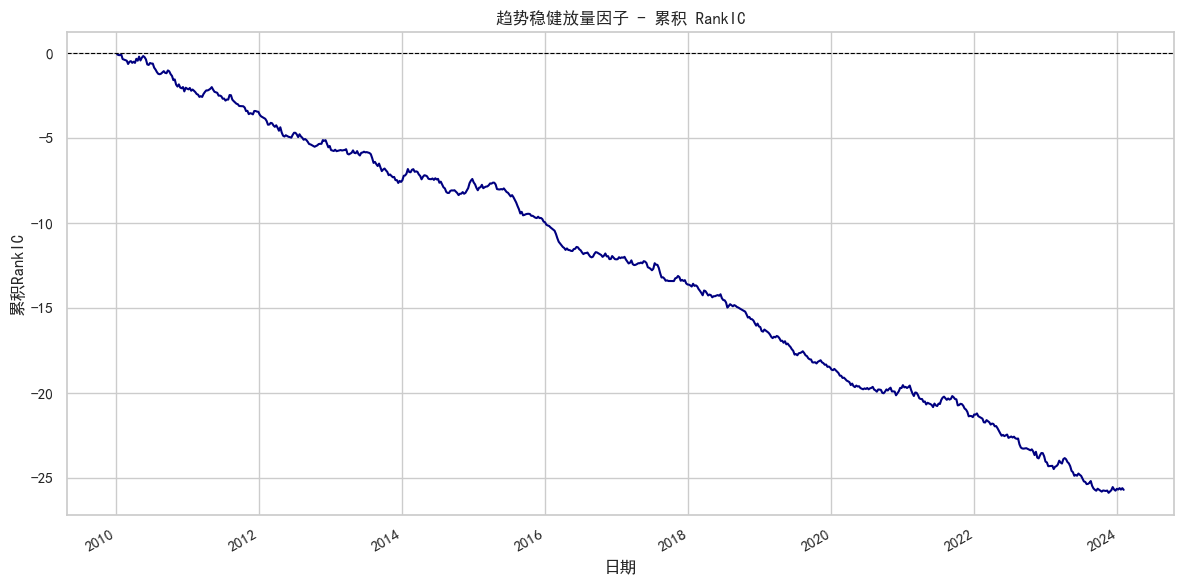

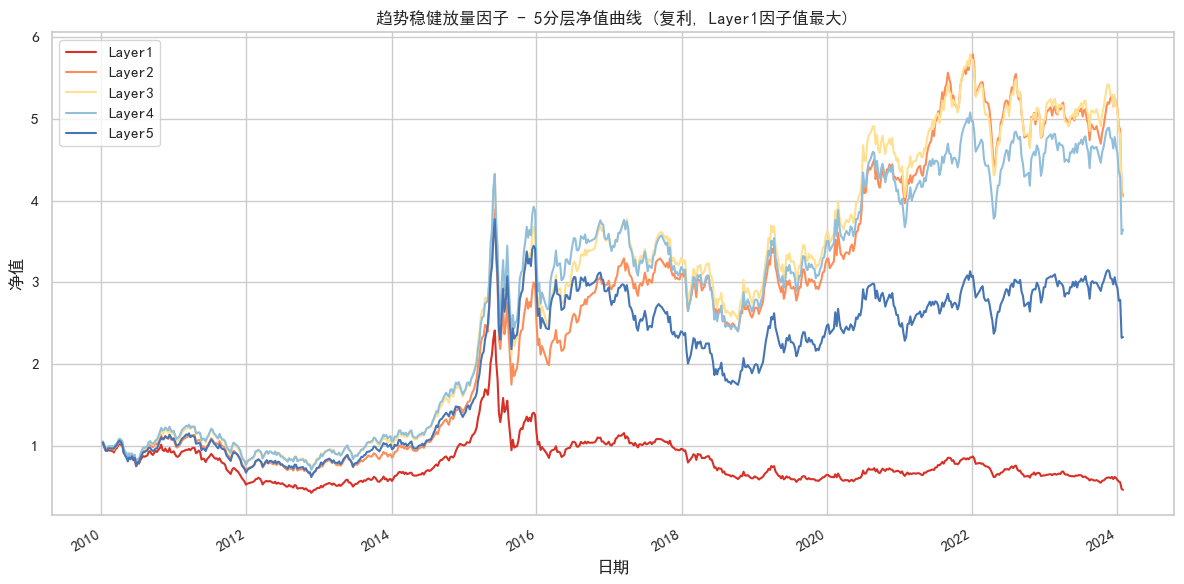

[EvalGPT] 正在生成评估报告...
[EvalGPT] 评估报告生成完成。


In [14]:
# 调用 EvalGPT 对优化后的因子进行回测评估
print("【EvalGPT】对优化后的因子进行回测评估...")

eval_result_2 = eval_agent.evaluate(factor_2, result_2)

In [15]:
# 打印优化后的因子的评估报告并比较优化前后的回测指标
if "error" in eval_result_2:
    print(f"【EvalGPT】评估出错: {eval_result_2['error']}")
else:
    print("\n【EvalGPT】优化后因子的评估报告】")
    print(eval_result_2['report'])
    
    print("【优化前后对比】")
    print(f"\n原因子 IC均值: {eval_result['metrics']['IC_Mean']:.4f}")
    print(f"优化后 IC均值: {eval_result_2['metrics']['IC_Mean']:.4f}")
    print(f"\n原因子 RankIC均值: {eval_result['metrics']['RankIC_Mean']:.4f}")
    print(f"优化后 RankIC均值: {eval_result_2['metrics']['RankIC_Mean']:.4f}")
    print(f"\n原因子 多空年化收益: {eval_result['metrics']['CAGR']:.2%}")
    print(f"优化后 多空年化收益: {eval_result_2['metrics']['CAGR']:.2%}")


【EvalGPT】优化后因子的评估报告】
【量价因子评估结果】
根据您提供的回测结果，我对“趋势稳健放量因子”的评估如下：
1.  **因子方向与预期严重不符，但具备一定收益能力**：因子构建逻辑旨在筛选“趋势稳健且放量”的强势股，预期其为正向因子（因子值越大，未来收益越高）。然而，回测显示其RankIC均值为-0.0364，为负值，且IC与RankIC的IR均为负。这表明该因子在历史回测中表现出稳定的**反向预测能力**，即因子值越大（趋势越强、放量越明显），未来收益反而倾向于越低。虽然方向与设计初衷相悖，但其多空年化收益达11.50%，说明这一反向信号具备转化为实际策略收益的潜力。
2.  **因子稳定性较差**：尽管RankIC均值的绝对值（0.0364）显示因子具有一定的选股区分度，但其RankIC_IR仅为-0.3171，绝对值远低于0.5。这意味着因子的RankIC序列波动较大，稳定性不足，在实际应用中可能出现较长周期的失效或反复。
3.  **结论**：当前因子并非一个稳定有效的正向趋势跟随因子，而是一个波动较大的“反向趋势/放量”因子。其收益可能源于市场对短期强势股（趋势加速且放量）的过度反应或获利了结压力。

【量价因子优化建议】
考虑到优化原则（提高IC绝对值、降低IC标准差、提高收益率），并基于该因子当前呈现的反向特性，建议遵循以下两种路径之一进行优化。路径一旨在将其改造为更稳健的正向因子，路径二则旨在强化其现有的反向逻辑。

**路径一：改造为正向因子（调整量价关系逻辑）**
核心思路是修正原因子中可能导致“强势股未来表现差”的逻辑环节，寻找真正能预示未来上涨的“健康”量价模式。
1.  **改变量价关系模式**：将“趋势强度”与“放量”的简单相乘关系，调整为更具经济学意义的模式。例如，将成交量因子作为对趋势因子的**条件过滤或平滑器**，而非直接相乘。
    *   **建议公式修改为**：
        `CS_Rank(`
        `    TS_Mean(`
        `        If(`
        `            CS_Rank(Log(Div(TS_Mean(S_DQ_VOLUME, 5), TS_Mean(S_DQ_VOLUME, 60)))) > 0.7, // 条件：成交量处于前30